In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             recall_score, balanced_accuracy_score, f1_score)

In [3]:
from datasets import load_dataset

dataset = load_dataset("marmal88/skin_cancer")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})


In [4]:
df = pd.DataFrame(dataset['train'])
print(df.head())
df.shape

                                               image      image_id  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024329   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024372   
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024418   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024450   
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024463   

     lesion_id                 dx dx_type   age     sex     localization  
0  HAM_0002954  actinic_keratoses   histo  75.0  female  lower extremity  
1  HAM_0005389  actinic_keratoses   histo  70.0    male  lower extremity  
2  HAM_0003380  actinic_keratoses   histo  75.0  female  lower extremity  
3  HAM_0005505  actinic_keratoses   histo  50.0    male  upper extremity  
4  HAM_0004568  actinic_keratoses   histo  50.0    male  upper extremity  


(9577, 8)

In [5]:
df.info()
df.describe().T
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9577 entries, 0 to 9576
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image         9577 non-null   object 
 1   image_id      9577 non-null   object 
 2   lesion_id     9577 non-null   object 
 3   dx            9577 non-null   object 
 4   dx_type       9577 non-null   object 
 5   age           9522 non-null   float64
 6   sex           9577 non-null   object 
 7   localization  9577 non-null   object 
dtypes: float64(1), object(7)
memory usage: 598.7+ KB


['image',
 'image_id',
 'lesion_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization']

In [6]:
print("\nMissing values per column:")
display(df.isnull().sum())

print('\nDuplicate values per column:')
display(df.drop(columns=['image']).duplicated().sum())


Missing values per column:


image            0
image_id         0
lesion_id        0
dx               0
dx_type          0
age             55
sex              0
localization     0
dtype: int64


Duplicate values per column:


np.int64(0)

In [ ]:
print('\nFill missing values in \'age\' with the most common age:')
df['age'] = df['age'].fillna(df['age'].median())
display(df.isnull().sum())

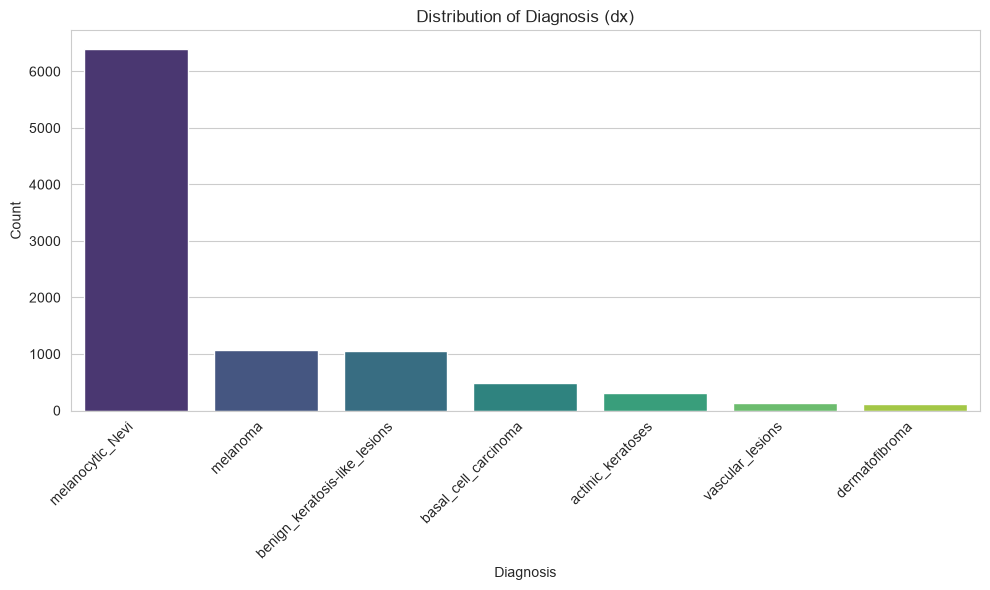

In [7]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

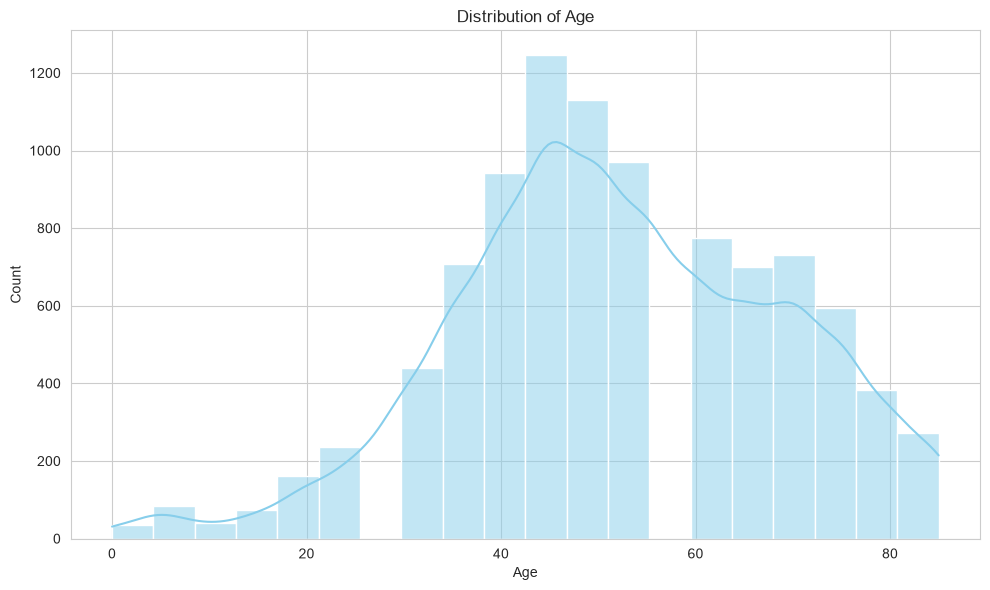

In [8]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

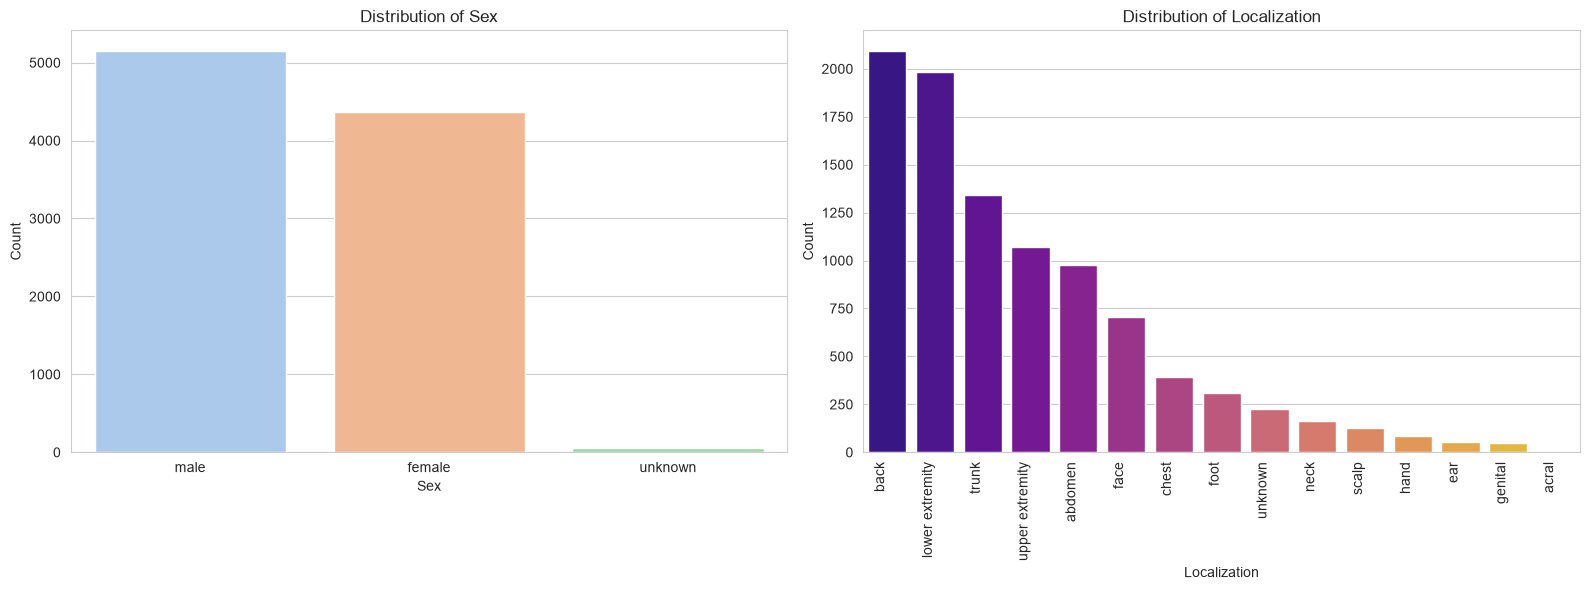

In [9]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel', order=df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='localization', ax=axes[1], palette='plasma', order=df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

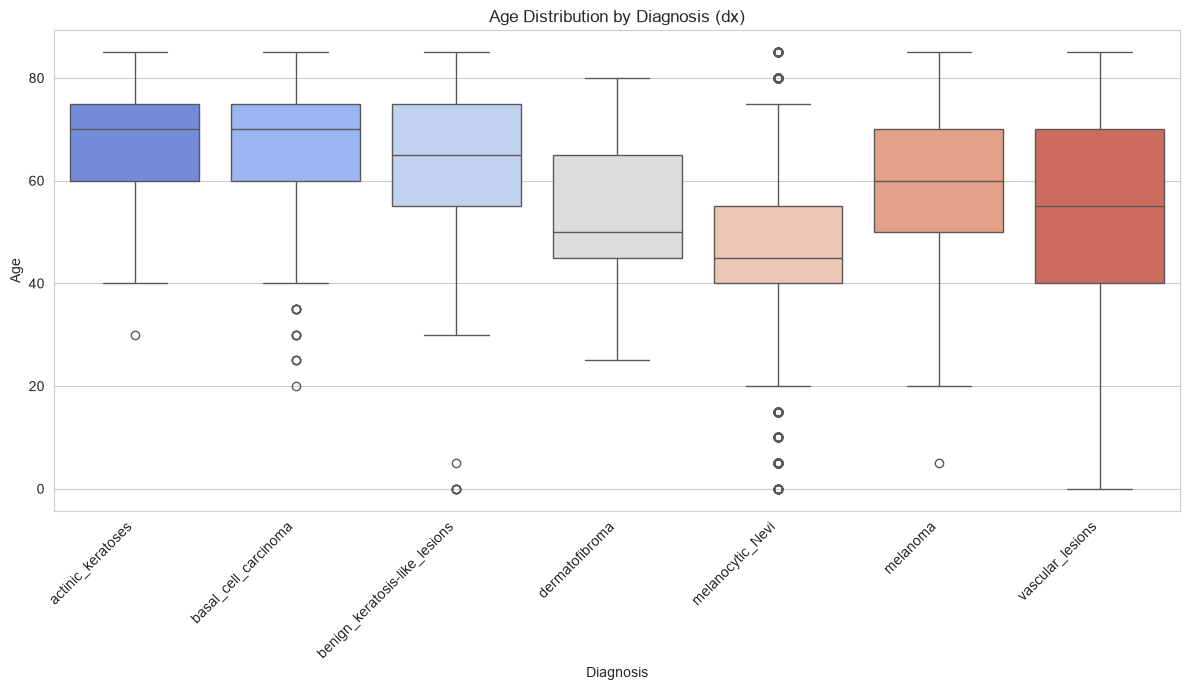

In [10]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_encoded = pd.get_dummies(df, columns=['dx'], prefix='dx')

# Display the first few rows of the DataFrame with the new encoded columns
display(df_encoded.head())

# Display the names of the new columns created by one-hot encoding
print(f"\nNew columns created: {df_encoded.columns[df_encoded.columns.str.startswith('dx_')].tolist()}")

,image,image_id,lesion_id,dx_type,age,sex,localization,dx_actinic_keratoses,dx_basal_cell_carcinoma,dx_benign_keratosis-like_lesions,dx_dermatofibroma,dx_melanocytic_Nevi,dx_melanoma,dx_vascular_lesions
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024329,HAM_0002954,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024372,HAM_0005389,histo,70.0,male,lower extremity,True,False,False,False,False,False,False
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024418,HAM_0003380,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024450,HAM_0005505,histo,50.0,male,upper extremity,True,False,False,False,False,False,False
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024463,HAM_0004568,histo,50.0,male,upper extremity,True,False,False,False,False,False,False



New columns created: ['dx_type', 'dx_actinic_keratoses', 'dx_basal_cell_carcinoma', 'dx_benign_keratosis-like_lesions', 'dx_dermatofibroma', 'dx_melanocytic_Nevi', 'dx_melanoma', 'dx_vascular_lesions']


## Prepare labels to split Train/Test sets and handle Class Imbalance

In [12]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Label shape:", y.shape)

Classes: [(0, 'actinic_keratoses'), (1, 'basal_cell_carcinoma'), (2, 'benign_keratosis-like_lesions'), (3, 'dermatofibroma'), (4, 'melanocytic_Nevi'), (5, 'melanoma'), (6, 'vascular_lesions')]
Label shape: (9577,)


In [13]:
def image_to_array(example, size=(32, 32)):
    """Convert a Hugging Face/Pillow image to a normalized RGB array."""
    image = example["image"].convert("RGB").resize(size)
    return np.asarray(image, dtype=np.float32) / 255.0

# Decode and resize images only when they are actually needed for modeling.
X = np.stack([image_to_array(example) for example in dataset["train"]])

print("Image array shape:", X.shape)
print("Image value range:", float(X.min()), "to", float(X.max()))

Image array shape: (9577, 32, 32, 3)
Image value range: 0.0 to 1.0


In [14]:
# Split the dataset into train/test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (7661, 32, 32, 3) (7661,)
Test set: (1916, 32, 32, 3) (1916,)


In [15]:
# Handle Class Imbalance


classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.34297052154195, 1: 2.813441057656996, 2: 1.30600068189567, 3: 12.436688311688311, 4: 0.21358871417419426, 5: 1.2711133233781318, 6: 10.040629095674968}


## Random Forest Model

In [16]:
# Train Random Forest Classifier


X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

print("Random Forest training shape:", X_train_rf.shape)
print("Random Forest test shape:", X_test_rf.shape)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)


Random Forest training shape: (7661, 3072)
Random Forest test shape: (1916, 3072)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 4.34297052154195, 1: 2.813441057656996, 2: 1.30600068189567, 3: 12.436688311688311, ...}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of 

Random Forest Accuracy: 0.673277661795407
Random Forest Balanced Accuracy: 0.47029800342567313

Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses       0.45      0.43      0.44        63
         basal_cell_carcinoma       0.37      0.58      0.45        98
benign_keratosis-like_lesions       0.39      0.48      0.43       210
               dermatofibroma       0.75      0.27      0.40        22
             melanocytic_Nevi       0.88      0.76      0.82      1281
                     melanoma       0.36      0.55      0.44       215
             vascular_lesions       0.60      0.22      0.32        27

                     accuracy                           0.67      1916
                    macro avg       0.54      0.47      0.47      1916
                 weighted avg       0.73      0.67      0.69      1916



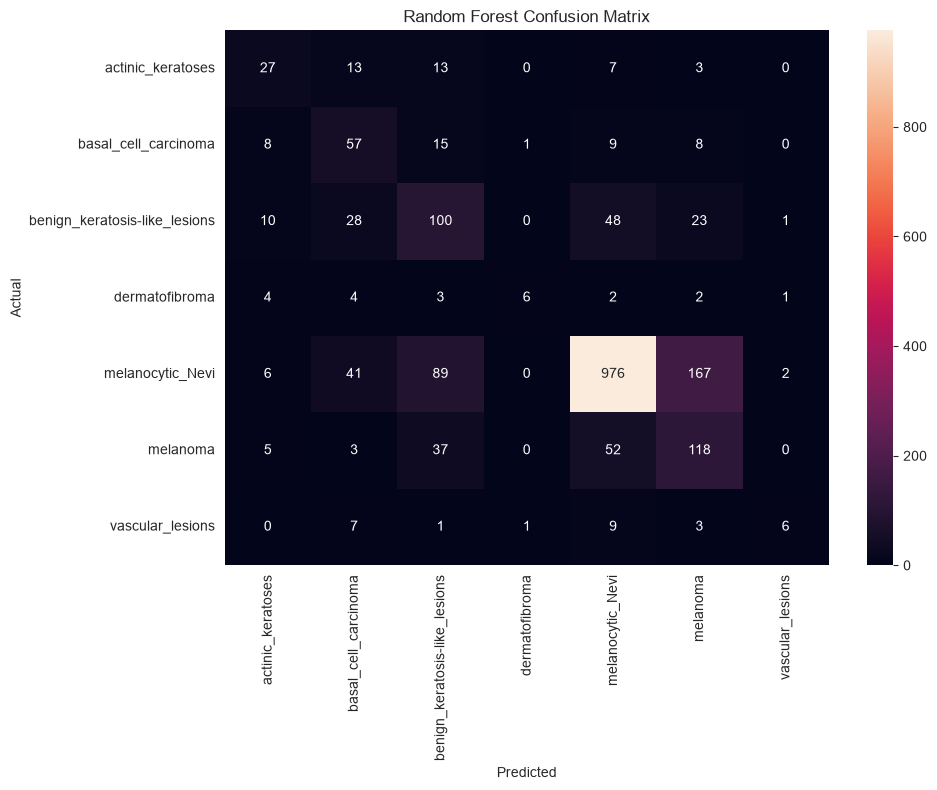

In [17]:
# Evaluate Random Forest Model

rf_predictions = rf_model.predict(X_test_rf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Random Forest Balanced Accuracy:", balanced_accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, rf_predictions, labels=np.arange(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LSTM Model

In [18]:
# Train LSTM Classifier

RUN_LSTM = True

if RUN_LSTM:
    import tensorflow as tf

    tf.random.set_seed(42)

    # Treat image rows as sequence steps; width × channels are features.
    X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax"),
    ])

    lstm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    lstm_model.fit(
        X_train_lstm,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        class_weight=class_weights,
        verbose=1,
    )

    test_loss, test_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)
    print("LSTM test loss:", test_loss)
    print("LSTM test accuracy:", test_accuracy)
else:
    print("LSTM training skipped. Set RUN_LSTM = True to enable it.")

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1348 - loss: 1.9905 - val_accuracy: 0.1220 - val_loss: 2.0499
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2632 - loss: 1.9805 - val_accuracy: 0.4494 - val_loss: 1.7897
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3913 - loss: 1.9498 - val_accuracy: 0.4684 - val_loss: 1.8501
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4205 - loss: 1.9142 - val_accuracy: 0.5023 - val_loss: 1.5635
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4391 - loss: 1.8768 - val_accuracy: 0.5062 - val_loss: 1.4478
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4408 - loss: 1.8134 - val_accuracy: 0.4468 - val_loss: 1.7181
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4342 - loss: 1.7668 - val_accuracy: 0.4886 - val_loss: 1.4962
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4545 - loss: 1.7384 - val_accuracy: 0.5075 - v

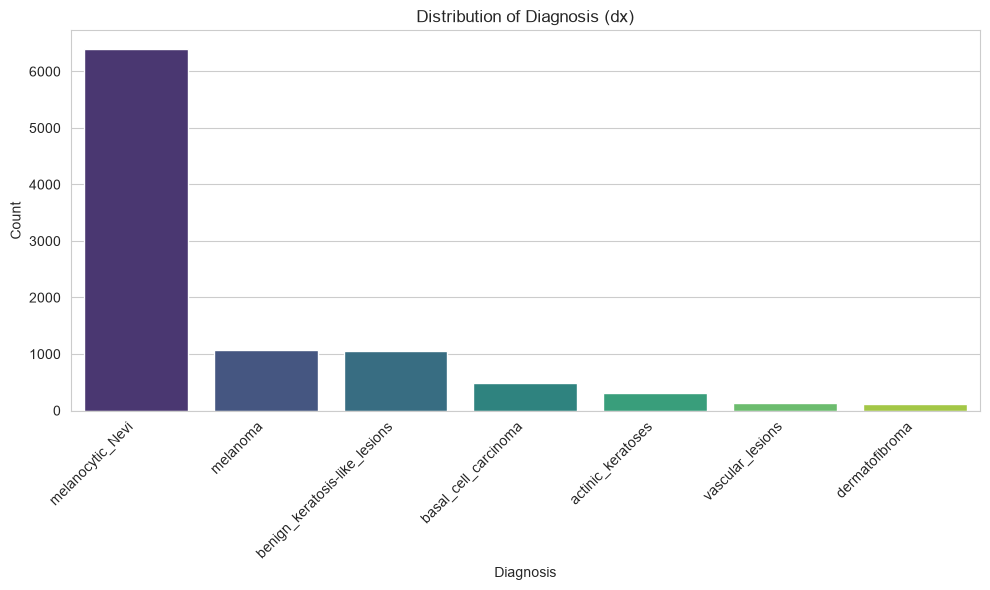

In [19]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()